In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from qubo_utils import build_Q,check_validity,execute_qaoa_and_get_results,linear_ramp_parameters

edges = [
    (0,1),
    (0,2),
    (1,2),
    (1,3),
    (2,3),
    (2,4),
    (3,4)
]

edge_names = ["01","02","12","13","23","24","34"]

costs = [2,4,1,3,2,5,1]

nodes = [0,1,2,3,4]

targets = {
    0: 1,   # source
    4: -1,  # sink
    1: 0,
    2: 0,
    3: 0
}

Q = build_Q(costs, edges, nodes, targets)
print(Q.shape)
print(Q)

(7, 7)
[[ 2.  6. -6. -6.  0.  0.  0.]
 [ 0.  4.  6.  0. -6. -6.  0.]
 [ 0.  0.  7.  6. -6. -6.  0.]
 [ 0.  0.  0.  9.  6.  0. -6.]
 [ 0.  0.  0.  0.  8.  6. -6.]
 [ 0.  0.  0.  0.  0.  5.  6.]
 [ 0.  0.  0.  0.  0.  0.  1.]]


The constructed 7×7 QUBO matrix is used as input for QAOA.

In [2]:
from qat.opt import QUBO
import numpy as np

# Make Q symmetric
Q = -((Q + Q.T) / 2)

print("Q matrix:")
print(Q)

# Create QUBO object
qubo = QUBO(Q)

Q matrix:
[[-2. -3.  3.  3. -0. -0. -0.]
 [-3. -4. -3. -0.  3.  3. -0.]
 [ 3. -3. -7. -3.  3.  3. -0.]
 [ 3. -0. -3. -9. -3. -0.  3.]
 [-0.  3.  3. -3. -8. -3.  3.]
 [-0.  3.  3. -0. -3. -5. -3.]
 [-0. -0. -0.  3.  3. -3. -1.]]


The matrix is made symmetric and its sign is flipped to convert the problem into a maximization form required by QAOA.Finally, the matrix is converted into a QUBO object.    

In [ ]:
# Create QAOA job
job = qubo.qaoa_job(1, False)

# Extract circuit
circuit = job.circuit

# Display circuit
circuit.display()

num_gates = len(circuit.ops)
print("Number of gates:", num_gates)

# Print gates used in the circuit
print("\nGates used in the circuit:")

for i, op in enumerate(circuit.ops):
    print(f"Gate {i+1}: {op}")

Number of gates: 35

Gates used in the circuit:
Gate 1: Op(gate='H', qbits=[0], type=0, cbits=None, formula=None, remap=None)
Gate 2: Op(gate='H', qbits=[1], type=0, cbits=None, formula=None, remap=None)
Gate 3: Op(gate='H', qbits=[2], type=0, cbits=None, formula=None, remap=None)
Gate 4: Op(gate='H', qbits=[3], type=0, cbits=None, formula=None, remap=None)
Gate 5: Op(gate='H', qbits=[4], type=0, cbits=None, formula=None, remap=None)
Gate 6: Op(gate='H', qbits=[5], type=0, cbits=None, formula=None, remap=None)
Gate 7: Op(gate='H', qbits=[6], type=0, cbits=None, formula=None, remap=None)
Gate 8: Op(gate='_0', qbits=[2, 4], type=0, cbits=None, formula=None, remap=None)
Gate 9: Op(gate='_0', qbits=[1, 5], type=0, cbits=None, formula=None, remap=None)
Gate 10: Op(gate='_0', qbits=[0, 3], type=0, cbits=None, formula=None, remap=None)
Gate 11: Op(gate='_1', qbits=[6], type=0, cbits=None, formula=None, remap=None)
Gate 12: Op(gate='_2', qbits=[1, 2], type=0, cbits=None, formula=None, remap=No

In [4]:
# Create QAOA job (8 layers)
job = qubo.qaoa_job(6,False)
circuit = job.circuit

# Display circuit
circuit.display()

A QAOA job is created from the QUBO model using 8 layers(depth = 8).The circuit corresponding to this QAOA job is then generated and displayed to visualize the quantum operations.

In [5]:
from qat.qpus import get_default_qpu
#Initialize QPU
qpu = get_default_qpu()

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


A default QPU (simulator) is initialized and used to execute the LR-QAOA circuit.

In [6]:
#result = qpu.submit(job)
#param_map = result.parameter_map
# Linear-ramp schedule parameters
delta_beta = 0.5
delta_gamma = -0.5

# Generate fixed LR-QAOA parameters
param_map = linear_ramp_parameters(6, delta_beta, delta_gamma)
#print(param_map)

bitstrings, probabilities, final_result = execute_qaoa_and_get_results(circuit, qpu, param_map, Q,nbshots=0)
print(bitstrings)
print(probabilities)

['0000000', '0000001', '0000010', '0000011', '0000100', '0000101', '0000110', '0000111', '0001000', '0001001', '0001010', '0001011', '0001100', '0001101', '0001110', '0001111', '0010000', '0010001', '0010010', '0010011', '0010100', '0010101', '0010110', '0010111', '0011000', '0011001', '0011010', '0011011', '0011100', '0011101', '0011110', '0011111', '0100000', '0100001', '0100010', '0100011', '0100100', '0100101', '0100110', '0100111', '0101000', '0101001', '0101010', '0101011', '0101100', '0101101', '0101110', '0101111', '0110000', '0110001', '0110010', '0110011', '0110100', '0110101', '0110110', '0110111', '0111000', '0111001', '0111010', '0111011', '0111100', '0111101', '0111110', '0111111', '1000000', '1000001', '1000010', '1000011', '1000100', '1000101', '1000110', '1000111', '1001000', '1001001', '1001010', '1001011', '1001100', '1001101', '1001110', '1001111', '1010000', '1010001', '1010010', '1010011', '1010100', '1010101', '1010110', '1010111', '1011000', '1011001', '1011010'

The Linear-Ramp QAOA (LR-QAOA) parameters are generated using predefined linear schedules for the mixer Hamiltonian (β) and cost Hamiltonian (γ) instead of using classically optimized QAOA parameters. The parameters are assigned to the QAOA circuit and executed on the QPU simulator with nbshots = 0 to obtain the exact probability distribution. The measured bitstrings and their corresponding probabilities are then collected and printed.

In [7]:
costs_list = []
valid_flags = []

num_edges = len(edges)

for sample in final_result:

    bitstring = sample.state.bitstring.zfill(Q.shape[0])

    edge_bits = bitstring[:num_edges]

    bits = [int(b) for b in edge_bits]   # convert to list of ints

    #selected_edges = [edges[i] for i, b in enumerate(bits) if b == 1]

    path_cost = sum(costs[i] for i, b in enumerate(bits) if b == 1)

    valid = check_validity(bits, edges, nodes, targets)

    costs_list.append(path_cost)
    valid_flags.append(valid)

for b, c, v, p in zip(bitstrings, costs_list, valid_flags,probabilities):
  if v:
    print("Bitstring:", b, "| Path cost:", c,"| Probability:", p,"| Valid:",v)

Bitstring: 0100010 | Path cost: 9 | Probability: 0.047508048634559326 | Valid: True
Bitstring: 0100101 | Path cost: 7 | Probability: 0.07165847064873515 | Valid: True
Bitstring: 1001001 | Path cost: 6 | Probability: 0.0747687469905166 | Valid: True
Bitstring: 1010010 | Path cost: 8 | Probability: 0.05767323550526149 | Valid: True
Bitstring: 1010101 | Path cost: 6 | Probability: 0.0997360444984623 | Valid: True


Each measured bitstring is processed to compute the corresponding path cost and check its validity based on the given constraints. The results are stored and only the valid solutions along with their costs and probabilities are displayed.

In [8]:
best_cost = float('inf')
best_bitstring = None
best_prob = -1

# Find the best valid solution
for c, v, b, p in zip(costs_list, valid_flags, bitstrings, probabilities):
    if v:
        if (c < best_cost) or (c == best_cost and p > best_prob):
            best_cost = c
            best_bitstring = b
            best_prob = p
# Print best solution 
print("Best valid bitstring:", best_bitstring)
print("Best valid cost:", best_cost)

if best_bitstring is not None:
    bits = [int(b) for b in best_bitstring]
    edge_bits = bits[:num_edges]

    best_path_edges = [
    edges[i] for i, b in enumerate(edge_bits) if b == 1
    ]

    print("Best valid path :", best_path_edges)
else:
    print("No valid solution found")
    
print("Probability of best solution:", best_prob)

Best valid bitstring: 1010101
Best valid cost: 6
Best valid path : [(0, 1), (1, 2), (2, 3), (3, 4)]
Probability of best solution: 0.0997360444984623


The valid solution with the minimum cost is identified using the computed costs_list, valid_flags and bitstrings.Its corresponding probability is obtained from probabilities and the bitstring is used to extract the selected edges representing the path.The best valid solution along with its cost, path and probability is displayed.

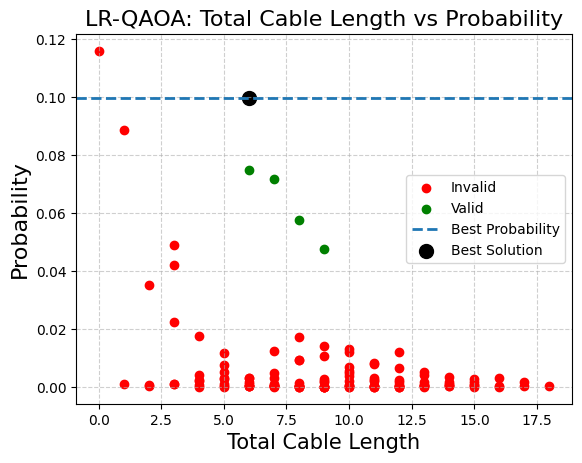

In [9]:
import matplotlib.pyplot as plt

# valid
valid_x = [c for c, v in zip(costs_list, valid_flags) if v]
valid_y = [p for p, v in zip(probabilities, valid_flags) if v]

# invalid
invalid_x = [c for c, v in zip(costs_list, valid_flags) if not v]
invalid_y = [p for p, v in zip(probabilities, valid_flags) if not v]

# Plot
plt.scatter(invalid_x, invalid_y, color='red', label='Invalid')
plt.scatter(valid_x, valid_y, color='green', label='Valid')


# mark best probability 
if best_prob is not None:
    plt.axhline(y=best_prob, linestyle='--', linewidth=2, label='Best Probability')

# Plot the optimal solution point
    plt.scatter(best_cost, best_prob, s=100, color='black', label='Best Solution')

plt.xlabel("Total Cable Length", fontsize=15)
plt.ylabel("Probability", fontsize=16)
plt.title("LR-QAOA: Total Cable Length vs Probability", fontsize=16)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The costs and probabilities are plotted for both valid and invalid solutions using a scatter plot. The best solution is highlighted based on its cost and probability, providing a clear view of the QAOA results.